# 4.2. Identifying Wildfire Hotspots in Portugal

This notebook demonstrates the application of HDBSCAN clustering to identify wildfire hotspots in Portugal using burned area data from 2020 to 2024.

<a href="https://colab.research.google.com/github/les2feup/geo-clustering/blob/main/02_Wildfire_Hotspots_in_Portugal.ipynb" target="_blank">
  <img src="https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=for-the-badge&logo=googlecolab&logoColor=white" alt="Open In Colab"/>
</a>

**Context**

Wildfire events do not occur uniformly across landscapes: some areas experience dense concentrations of incidents in close proximity, while others exhibit sparse and dispersed patterns. HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) efficiently handles spatial heterogeneity by adapting to local density variations, enabling the identification of both tightly concentrated hotspots and looser spatial aggregations without imposing a uniform distance parameter.

**Objective**: Identify wildfire hotspots and spatial patterns in Portugal's burned areas.

**Application**:
- Apply HDBSCAN to wildfire occurrence data
- Adapt to varying spatial densities across the landscape
- Identify both concentrated hotspots and dispersed fire patterns
- Distinguish noise (isolated events) from clustered incidents

**What it reveals**:
- High-risk zones with recurring wildfires in close proximity
- Spatial heterogeneity in fire occurrence patterns
- Isolated fire events versus systematic clustering
- Regional variations in wildfire density

**Visualization**:
- Map with HDBSCAN clusters showing varying densities
- Noise points representing isolated fire events

**Load the dataset**

In [1]:
# Load previously saved data (much faster than fetching from WFS)
import geopandas as gpd
from pathlib import Path
import os

saved_file = Path("data/02_portugal_burned_areas_2020_2024.gpkg")
figures_dir = Path("figures")

# Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Download from GitHub if file doesn't exist locally
if not saved_file.exists():
    print("Downloading data from GitHub...")
    import urllib.request

    github_url = "https://github.com/les2feup/geo-clustering/raw/main/data/02_portugal_burned_areas_2020_2024.gpkg"

    try:
        urllib.request.urlretrieve(github_url, saved_file)
        print(f"✓ Downloaded to {saved_file}")
    except Exception as e:
        print(f"✗ Error downloading file: {e}")
        print("You may need to run the data fetching notebook first.")

# Load the data
if saved_file.exists():
    gdf = gpd.read_file(saved_file)
    print(f"✓ Loaded {len(gdf)} burned areas from {saved_file}")
    print(f"  Years: {sorted(gdf['year'].unique())}")
else:
    print(f"✗ File not found: {saved_file}")
    print("Run the data fetching notebook to download the data.")

✓ Loaded 7775 burned areas from data/02_portugal_burned_areas_2020_2024.gpkg
  Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


**Convert geometries to centroids for clustering**

In [2]:
# Reproject to metric CRS for accurate centroid calculation
gdf_projected = gdf.to_crs(epsg=3763)  # Portuguese TM06/ETRS89

# Compute centroids in metric CRS
gdf_projected["centroid"] = gdf_projected.geometry.centroid

# Convert centroids back to geographic CRS for clustering
gdf_centroids = gdf_projected.set_geometry("centroid").to_crs(epsg=4326)

# Extract latitude and longitude for clustering
gdf["lat"] = gdf_centroids.geometry.y
gdf["lon"] = gdf_centroids.geometry.x

# coords = gdf[["lat", "lon"]].to_numpy()
# coords[:5]
gdf[['lat', 'lon', 'year']].head()

,lat,lon,year
0,41.690267,-8.752717,2020
1,41.788121,-8.729711,2020
2,41.870380,-8.523744,2020
3,38.887441,-9.283243,2020
4,37.292448,-7.615395,2020


**Filter data from 2024**

In [3]:
gdf_2024 = gdf[gdf["year"] == 2024].copy()  # Add .copy() to create independent DataFrame
coords_2024 = gdf_2024[["lat", "lon"]].to_numpy()

coords_2024[:5]

array([[42.0541681 , -8.25810349],
       [41.0053521 , -8.09863884],
       [41.59003407, -8.17579757],
       [41.74988143, -8.33203722],
       [41.80181144, -7.79600841]])

Plot the burned areas in Portugal for the year 2024.

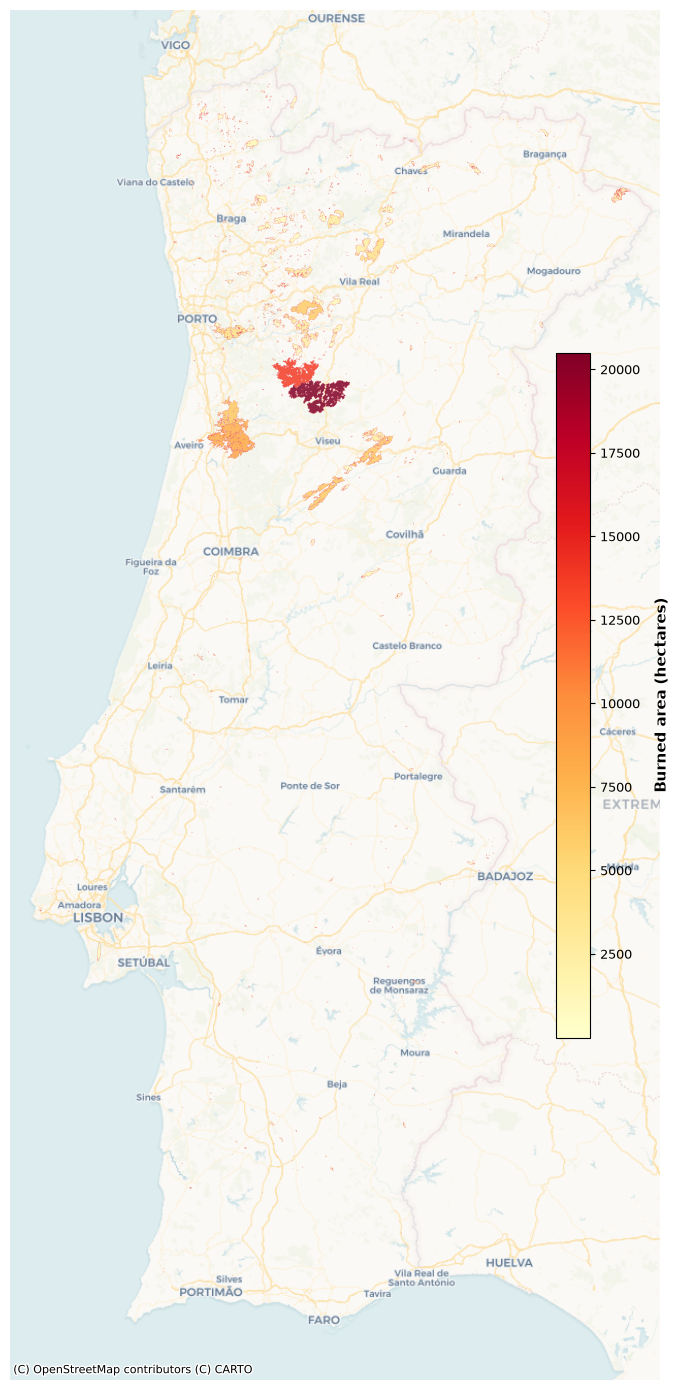

In [4]:
import contextily as cx
import matplotlib.pyplot as plt

YEAR = 2024

# Convert to Web Mercator for contextily basemap
plot_data = gdf_2024.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 14))

# Plot burned areas
plot_data.plot(
    ax=ax,
    column="AreaHaSIG",
    cmap="YlOrRd",
    linewidth=0.1,
    edgecolor="#E63946",
    legend=True,
    legend_kwds={
        "label": "Burned area (hectares)",
        "shrink": 0.5,
        "pad": -0.09,
        "aspect": 20,
    },
    alpha=0.85,
)

# Get the colorbar and adjust its position (vertical, inside map)
cbar = ax.get_figure().get_axes()[1]
cbar.set_position([0.82, 0.25, 0.025, 0.5])  # [left, bottom, width, height]
cbar.set_ylabel("Burned area (hectares)", fontsize=11, fontweight="bold", labelpad=10)
cbar.tick_params(labelsize=9)

# Add contextily basemap with Voyager style (more detailed than Positron)
cx.add_basemap(
    ax, crs=plot_data.crs.to_string(), source=cx.providers.CartoDB.Voyager, alpha=0.8
)

# ax.set_title("Portugal Burned Areas", fontsize=14, fontweight='bold', pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Clustering with HDBSCAN

In [5]:
import hdbscan
import numpy as np

clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric="haversine")
labels = clusterer.fit_predict(np.radians(coords_2024))

gdf_2024["cluster"] = labels

**Summary of the results**

Wildfire events distribution accross clusters in 2024:

In [6]:
gdf_2024["cluster"].value_counts().sort_index()

cluster
-1    374
 0     32
 1     37
 2     52
 3     50
 4     16
 5    945
 6     52
Name: count, dtype: int64

Average affected are a per cluster in 2024 (hectares):

In [7]:
gdf_2024.groupby("cluster")["AreaHaSIG"].mean()

cluster
-1     61.268272
 0     14.527867
 1      1.508798
 2      8.300688
 3      8.943000
 4     14.601910
 5    110.598211
 6    198.732156
Name: AreaHaSIG, dtype: float64

### Clustering data from 2020 to 2024

Now that we have seen the results for 2024, let's apply HDBSCAN to the entire dataset from 2020 to 2024 to identify broader wildfire hotspots over multiple years.

Load Portugal's NUTS3 regions to provide geographic context for the burned areas and clusters. We'll use data from the Portuguese government's open data portal.

In [8]:
import geopandas as gpd
import requests
from pathlib import Path
import io

# Using Eurostat GISCO for standardized NUTS regions
NUTS_URL = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson"

# Create a data directory if it doesn't exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

nuts_file = data_dir / "02_portugal_nuts3.gpkg"

if nuts_file.exists():
    print(f"Loading existing file: {nuts_file}")
    portugal_nuts3 = gpd.read_file(nuts_file)
else:
    print("Downloading NUTS3 boundaries from Eurostat...")

    try:
        # Download the GeoJSON
        response = requests.get(NUTS_URL, timeout=120)
        response.raise_for_status()

        # Load all NUTS3 regions
        all_nuts3 = gpd.read_file(io.BytesIO(response.content))

        # Filter for Portugal (country code 'PT')
        portugal_all = all_nuts3[all_nuts3["CNTR_CODE"] == "PT"].copy()

        # Filter for Continental Portugal only (exclude Azores PT2 and Madeira PT3)
        # Continental Portugal has NUTS codes starting with PT1
        portugal_nuts3 = portugal_all[
            portugal_all["NUTS_ID"].str.startswith("PT1")
        ].copy()

        # Save for future use
        portugal_nuts3.to_file(nuts_file, driver="GPKG")
        print(f"Saved to {nuts_file}")

    except Exception as e:
        print(f"  ✗ Error downloading from Eurostat: {e}")
        print("\nTrying alternative source (Portuguese districts)...")

        # Alternative: Use Portuguese districts from Natural Earth or OpenStreetMap
        # This is a fallback option
        try:
            import osmnx as ox

            portugal_nuts3 = ox.geocode_to_gdf("Portugal", which_result=1)
            print("  ✓ Loaded Portugal boundary from OSM (country level)")
        except Exception as e:
            print(f"  ✗ Could not load administrative boundaries: {e}")
            portugal_nuts3 = None

if portugal_nuts3 is not None:
    print("\nNUTS3 Regions Summary:")
    print(f"  • Number of regions: {len(portugal_nuts3)}")
    print(f"  • CRS: {portugal_nuts3.crs}")
    print("\nFirst few regions:")
    display(portugal_nuts3[["NUTS_ID", "NUTS_NAME", "geometry"]].head())

Loading existing file: data/02_portugal_nuts3.gpkg

NUTS3 Regions Summary:
  • Number of regions: 23
  • CRS: EPSG:4326

First few regions:


,NUTS_ID,NUTS_NAME,geometry
0,PT112,Cávado,"MULTIPOLYGON (((-8.05186 41.82061, -8.04515 41..."
1,PT119,Ave,"MULTIPOLYGON (((-8.02341 41.69686, -8.01741 41..."
2,PT11A,Área Metropolitana do Porto,"MULTIPOLYGON (((-8.77643 41.47197, -8.75399 41..."
3,PT16I,Médio Tejo,"MULTIPOLYGON (((-8.10868 39.94558, -8.09874 39..."
4,PT11E,Terras de Trás-os-Montes,"MULTIPOLYGON (((-6.75002 41.94353, -6.74173 41..."


In [16]:
def cluster_burned_areas_by_year(gdf, years):
    """
    Cluster burned areas by year using HDBSCAN and export results to CSV.

    Parameters:
    -----------
    gdf : GeoDataFrame
        Burned areas data with lat/lon coordinates
    years : list
        List of years to process

    Returns:
    --------
    None
        Exports clustered data to CSV files for each year
    """

    for year in years:
        # Filter data for current year
        gdf_year = gdf[gdf["year"] == year].copy()

        # Skip if no data for this year
        if len(gdf_year) == 0:
            continue

        # Extract coordinates for clustering
        coords = gdf_year[["lat", "lon"]].to_numpy()

        # Apply HDBSCAN clustering with haversine metric for geographic coordinates
        clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric="haversine")
        labels = clusterer.fit_predict(np.radians(coords))
        gdf_year["cluster"] = labels

        # Prepare export data with cluster assignments
        export_data = gdf_year[["AreaHaSIG", "lat", "lon", "cluster", "year"]].copy()
        export_data["is_noise"] = export_data["cluster"] == -1

        # Save clustered data to CSV
        output_file = f"data/02_burned_areas_clustered_{year}.csv"
        export_data.to_csv(output_file, index=False)
        print(f"✓ Saved clustered data for {year} to {output_file}")

    return

cluster_burned_areas_by_year(
    gdf=gdf, years=[2020, 2021, 2022, 2023, 2024]
)

✓ Saved clustered data for 2020 to data/02_burned_areas_clustered_2020.csv
✓ Saved clustered data for 2021 to data/02_burned_areas_clustered_2021.csv
✓ Saved clustered data for 2022 to data/02_burned_areas_clustered_2022.csv
✓ Saved clustered data for 2023 to data/02_burned_areas_clustered_2023.csv
✓ Saved clustered data for 2024 to data/02_burned_areas_clustered_2024.csv


In [13]:
def merge_clustered_data_with_nuts3(year, portugal_nuts3):
    """
    Load clustered burned area data from CSV and merge with NUTS3 regions.

    Parameters:
    -----------
    year : int
        Year to load clustered data for
    portugal_nuts3 : GeoDataFrame
        NUTS3 region boundaries

    Returns:
    --------
    tuple: (gdf_with_nuts, nuts_stats, nuts3_with_stats)
        - gdf_with_nuts: Burned areas with NUTS3 region info
        - nuts_stats: Statistics aggregated by NUTS3 region
        - nuts3_with_stats: NUTS3 boundaries with burned area statistics
    """

    if portugal_nuts3 is None:
        print("⚠️ NUTS3 data not available")
        return None, None, None

    # Load clustered data from CSV
    csv_file = f"data/burned_areas_clustered_{year}.csv"

    try:
        import pandas as pd

        df = pd.read_csv(csv_file)
        print(f"✓ Loaded {len(df)} clustered burned areas from {csv_file}")
    except FileNotFoundError:
        print(f"✗ File not found: {csv_file}")
        print("Run the clustering function first to generate the CSV files.")
        return None, None, None

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
    )

    # Ensure both GeoDataFrames are in the same CRS
    gdf_for_join = gdf.to_crs(portugal_nuts3.crs)

    # Spatial join: assign each burned area to its NUTS3 region
    gdf_with_nuts = gpd.sjoin(
        gdf_for_join,
        portugal_nuts3[["NUTS_ID", "NUTS_NAME", "geometry"]],
        how="left",
        predicate="intersects",
    )

    # Calculate statistics by NUTS3 region
    nuts_stats = (
        gdf_with_nuts.groupby("NUTS_NAME")
        .agg(
            {
                "AreaHaSIG": ["count", "sum", "mean", "max"],
                "cluster": [
                    lambda x: (
                        x.mode()[0] if len(x) > 0 and not x.mode().empty else -1
                    ),  # Most common cluster
                    lambda x: (x != -1).sum(),  # Count of clustered fires
                    lambda x: (
                        (x == -1).sum() / len(x) * 100 if len(x) > 0 else 0
                    ),  # Noise percentage
                    lambda x: (
                        len(set(x[x != -1])) if len(x[x != -1]) > 0 else 0
                    ),  # Number of unique clusters
                ],
            }
        )
        .round(2)
    )

    nuts_stats.columns = [
        "Fire_Count",
        "Total_Area_ha",
        "Mean_Area_ha",
        "Max_Area_ha",
        "Dominant_Cluster",
        "Clustered_Fires",
        "Noise_Pct",
        "N_Clusters",
    ]
    nuts_stats = nuts_stats.sort_values("Total_Area_ha", ascending=False)

    # Create a choropleth map showing total burned area by region
    nuts3_with_stats = portugal_nuts3.merge(
        nuts_stats.reset_index(), left_on="NUTS_NAME", right_on="NUTS_NAME", how="left"
    )

    # Fill NaN values with 0 for regions with no fires
    for col in [
        "Fire_Count",
        "Total_Area_ha",
        "Mean_Area_ha",
        "Max_Area_ha",
        "Clustered_Fires",
        "Noise_Pct",
        "N_Clusters",
    ]:
        nuts3_with_stats[col] = nuts3_with_stats[col].fillna(0)
    nuts3_with_stats["Dominant_Cluster"] = nuts3_with_stats["Dominant_Cluster"].fillna(
        -1
    )

    # Display summary as formatted DataFrame
    # print(f"\n» Burned Areas by NUTS3 Region ({year}):")
    # display(nuts_stats.head(15))

    # Save statistics to CSV
    output_csv = f"data/02_nuts3_burned_area_stats_{year}.csv"
    nuts3_with_stats.drop(columns="geometry").to_csv(output_csv, index=False)
    print(f"✓ Saved NUTS3 statistics to {output_csv}")

    return gdf_with_nuts, nuts_stats, nuts3_with_stats


# Process all years
for year in [2020, 2021, 2022, 2023, 2024]:
    gdf_nuts, stats, nuts3_stats = merge_clustered_data_with_nuts3(
        year=year, portugal_nuts3=portugal_nuts3
    )

✓ Loaded 1777 clustered burned areas from data/burned_areas_clustered_2020.csv
✓ Saved NUTS3 statistics to data/02_nuts3_burned_area_stats_2020.csv
✓ Loaded 918 clustered burned areas from data/burned_areas_clustered_2021.csv
✓ Saved NUTS3 statistics to data/02_nuts3_burned_area_stats_2021.csv
✓ Loaded 1786 clustered burned areas from data/burned_areas_clustered_2022.csv
✓ Saved NUTS3 statistics to data/02_nuts3_burned_area_stats_2022.csv
✓ Loaded 1736 clustered burned areas from data/burned_areas_clustered_2023.csv
✓ Saved NUTS3 statistics to data/02_nuts3_burned_area_stats_2023.csv
✓ Loaded 1558 clustered burned areas from data/burned_areas_clustered_2024.csv
✓ Saved NUTS3 statistics to data/02_nuts3_burned_area_stats_2024.csv


**Plot NUTS3 regions hotspots**

In [14]:
import pandas as pd
from pathlib import Path

# Load all years of NUTS3 statistics
files = {
    2020: "data/02_nuts3_burned_area_stats_2020.csv",
    2021: "data/02_nuts3_burned_area_stats_2021.csv",
    2022: "data/02_nuts3_burned_area_stats_2022.csv",
    2023: "data/02_nuts3_burned_area_stats_2023.csv",
    2024: "data/02_nuts3_burned_area_stats_2024.csv",
}

dfs = []
for year, fp in files.items():
    if Path(fp).exists():
        df = pd.read_csv(fp)
        df["Year"] = year
        dfs.append(df)
    else:
        print(f"⚠️ File not found: {fp}")

data = pd.concat(dfs, ignore_index=True)

# Define hotspot criteria: high clustered fires + low noise percentage
# A hotspot must have:
# - At least 10 clustered fires
# - Noise percentage below 50%
CLUSTERED_FIRE_THRESHOLD = 10
NOISE_THRESHOLD = 50

# Identify hotspots for each year
data['is_hotspot'] = (
    (data['Clustered_Fires'] >= CLUSTERED_FIRE_THRESHOLD) & 
    (data['Noise_Pct'] <= NOISE_THRESHOLD)
)

# Count how many years each region qualifies as a hotspot
hotspot_frequency = (
    data.groupby("NUTS_NAME")
    .agg(
        {
            "is_hotspot": "sum",  # Number of years as hotspot
            "Total_Area_ha": "sum",  # Total burned area over 5 years
            "Clustered_Fires": "mean",  # Average clustered fires
            "Noise_Pct": "mean",  # Average noise percentage
            "Fire_Count": "sum",  # Total fires over 5 years
            "Year": "nunique",  # Number of years with data
        }
    )
    .round(2)
)

hotspot_frequency.columns = [
    "Years_as_Hotspot",
    "Total_Area_ha",
    "Avg_Clustered_Fires",
    "Avg_Noise_Pct",
    "Total_Fires",
    "Years_Present",
]

# Persistent hotspots: regions that are hotspots in 3+ years
persistent_hotspots = hotspot_frequency[
    hotspot_frequency['Years_as_Hotspot'] >= 3
].sort_values(
    ['Years_as_Hotspot', 'Avg_Clustered_Fires', 'Avg_Noise_Pct'],
    ascending=[False, False, True]
)

print(f"» Hotspot Criteria:")
print(f"  • Clustered fires ≥ {CLUSTERED_FIRE_THRESHOLD}")
print(f"  • Noise percentage ≤ {NOISE_THRESHOLD}%")
print(f"\n» Persistent Hotspots (3+ years):")
display(persistent_hotspots)

» Hotspot Criteria:
  • Clustered fires ≥ 10
  • Noise percentage ≤ 50%

» Persistent Hotspots (3+ years):


,Years_as_Hotspot,Total_Area_ha,Avg_Clustered_Fires,Avg_Noise_Pct,Total_Fires,Years_Present
NUTS_NAME,,,,,,
Tâmega e Sousa,5,32474.16,148.2,15.56,911,5
Área Metropolitana do Porto,5,9835.36,81.6,15.82,520,5
Médio Tejo,5,11943.96,58.4,10.88,318,5
Alto Minho,4,17897.58,166.6,19.39,1058,5
Ave,4,20825.35,127.6,21.49,788,5
Cávado,4,4502.69,52.6,24.84,357,5
Viseu Dão Lafões,4,54454.91,46.6,32.94,342,5
Área Metropolitana de Lisboa,4,2809.08,35.6,15.78,214,5
Alto Tâmega,3,26428.88,86.0,27.02,609,5


Visualize persistent regions with high clustered fires and low noise percentage across multiple years:

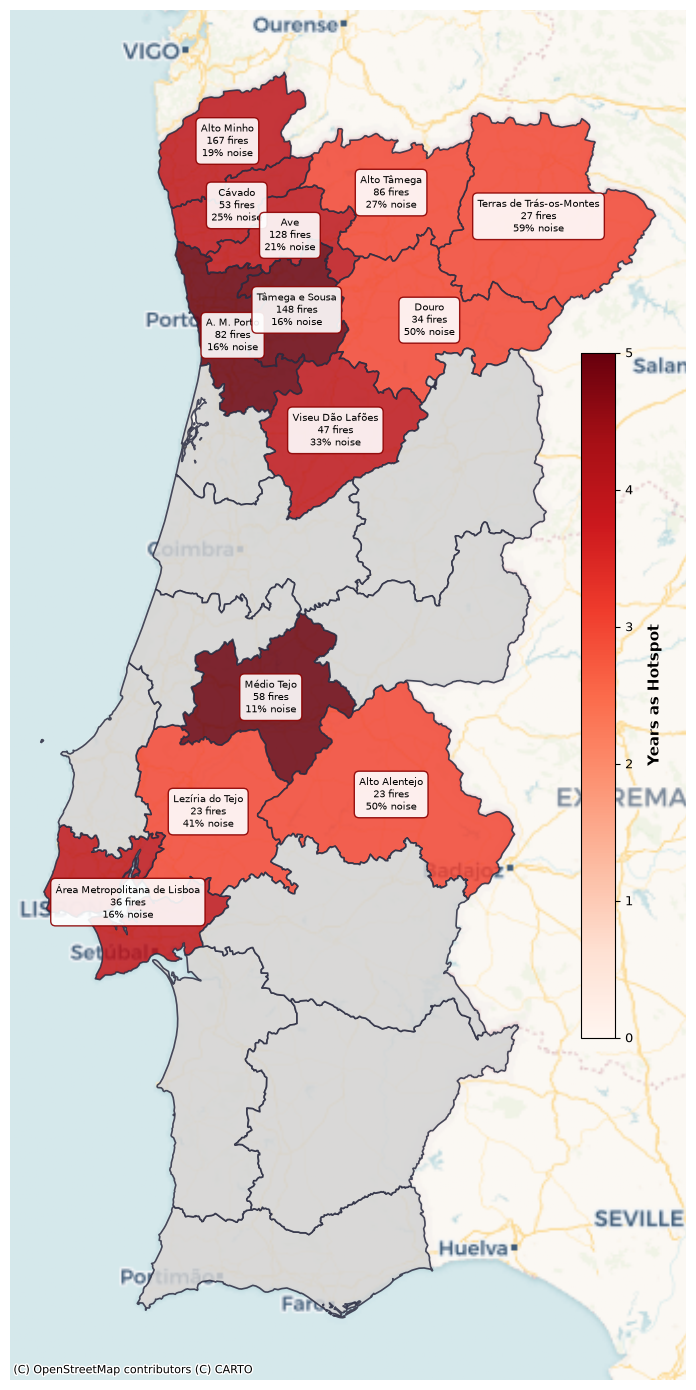

In [15]:
if portugal_nuts3 is not None and len(persistent_hotspots) > 0:
    # Merge persistent hotspot data with NUTS3 geometries
    nuts3_hotspots = portugal_nuts3.merge(
        persistent_hotspots.reset_index(),
        left_on="NUTS_NAME",
        right_on="NUTS_NAME",
        how="left",
    )

    # Convert to Web Mercator for contextily
    nuts3_hotspots_webm = nuts3_hotspots.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 14))

    # Plot choropleth colored by years as hotspot
    nuts3_hotspots_webm.plot(
        ax=ax,
        column="Years_as_Hotspot",
        cmap="Reds",
        linewidth=1.2,
        edgecolor="#2B2D42",
        legend=True,
        legend_kwds={
            "label": "Years as Hotspot (2020-2024)",
            "shrink": 0.5,
            "pad": -0.09,
            "aspect": 20,
        },
        alpha=0.85,
        vmin=0,
        vmax=5,
        missing_kwds={"color": "lightgray", "label": "Not a hotspot"},
    )

    # Get the colorbar and adjust its position
    cbar = ax.get_figure().get_axes()[1]
    cbar.set_position([0.82, 0.25, 0.025, 0.5])
    cbar.set_ylabel("Years as Hotspot", fontsize=11, fontweight="bold", labelpad=10)
    cbar.tick_params(labelsize=9)

    # Label persistent hotspots (3+ years)
    persistent_regions_webm = nuts3_hotspots_webm[
        nuts3_hotspots_webm["Years_as_Hotspot"] >= 3
    ]

    for idx, row in persistent_regions_webm.iterrows():
        centroid = row.geometry.centroid

        # Abbreviate region name if needed
        region_name = row["NUTS_NAME"]
        if region_name == "Área Metropolitana do Porto":
            region_name = "A. M. Porto"

        # Format label with key statistics
        label_text = (
            f"{region_name}\n"
            # f"{int(row['Years_as_Hotspot'])} yrs\n"
            f"{row['Avg_Clustered_Fires']:.0f} fires\n"
            f"{row['Avg_Noise_Pct']:.0f}% noise"
        )

        ax.text(
            centroid.x,
            centroid.y,
            label_text,
            fontsize=7,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor="white",
                alpha=0.9,
                edgecolor="darkred",
                linewidth=1,
            ),
        )

    # Add basemap
    cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.CartoDB.Voyager, alpha=1)

    ax.set_axis_off()
    plt.tight_layout()
    fig.savefig(figures_dir / "02_persistent_hotspots_map.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("⚠️ NUTS3 data or persistent hotspots not available for visualization")